In [1]:
## -- CHECK FOR 3rd PARTY LIBRARIES --
try:
    from pytorch_tabnet.tab_model import TabNetClassifier
    import skrub
except:
    %pip install -q pytorch-tabnet
    %pip install -q skrub

    from pytorch_tabnet.tab_model import TabNetClassifier
    import skrub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 650.3 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 585.9/585.9 kB 2.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'CPU: 4'

In [3]:
import numpy as np, pandas as pd, random
import matplotlib.pyplot as plt, seaborn as sns
from tqdm.notebook import tqdm
from time import time, sleep
import itertools

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor

from sklearn.calibration import CalibrationDisplay
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import balanced_accuracy_score, log_loss, RocCurveDisplay
from sklearn.preprocessing import TargetEncoder, LabelEncoder, StandardScaler, KBinsDiscretizer

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [4]:
## -- Global Settings --
# sklearn.set_config(transform_output="pandas")

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Configuration --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RESET': '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [5]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e7/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = '/kaggle/input/datasets/ziya07/college-student-health-behavior-dataset/'
    orig = pd.read_csv(ORIG_PATH+'student_health_dataset_50k.csv')
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/-- shared_notebooks --/Ps6e7 | Student Health/_student_health_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')
    orig = pd.read_csv(PATH+'student_health_dataset_50k.csv')

## =================================================================================

ID = 'id'
TARGET  = 'health_condition'
OBJECTS = train.select_dtypes(include=['object', 'category']).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

# ## -- Fill categorical --
# train[CATS] = train[CATS].fillna('missing')
# test[CATS]  = test[CATS].fillna('missing')
# orig[CATS]  = orig[CATS].fillna('missing')

# {c: i for i, c in enumerate(train[TARGET].unique())}
mapping   = {'fit': 0, 'at-risk': 1, 'unhealthy': 2}
r_mapping = {v: k for k, v in mapping.items()}

# for df in [train, orig]:
#     df[TARGET] = df[TARGET].map(mapping)

for (name, df) in {'Train': train, 'Test': test, 'Orig': orig}.items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (690088, 15)
Test shape: (295753, 14)
Orig shape: (50000, 16)

Total Numerical: 7
Total Categorical: 6
Total base features: 13


In [6]:
display(train.head())
train.info()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

In [7]:
train[NUMS].describe()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


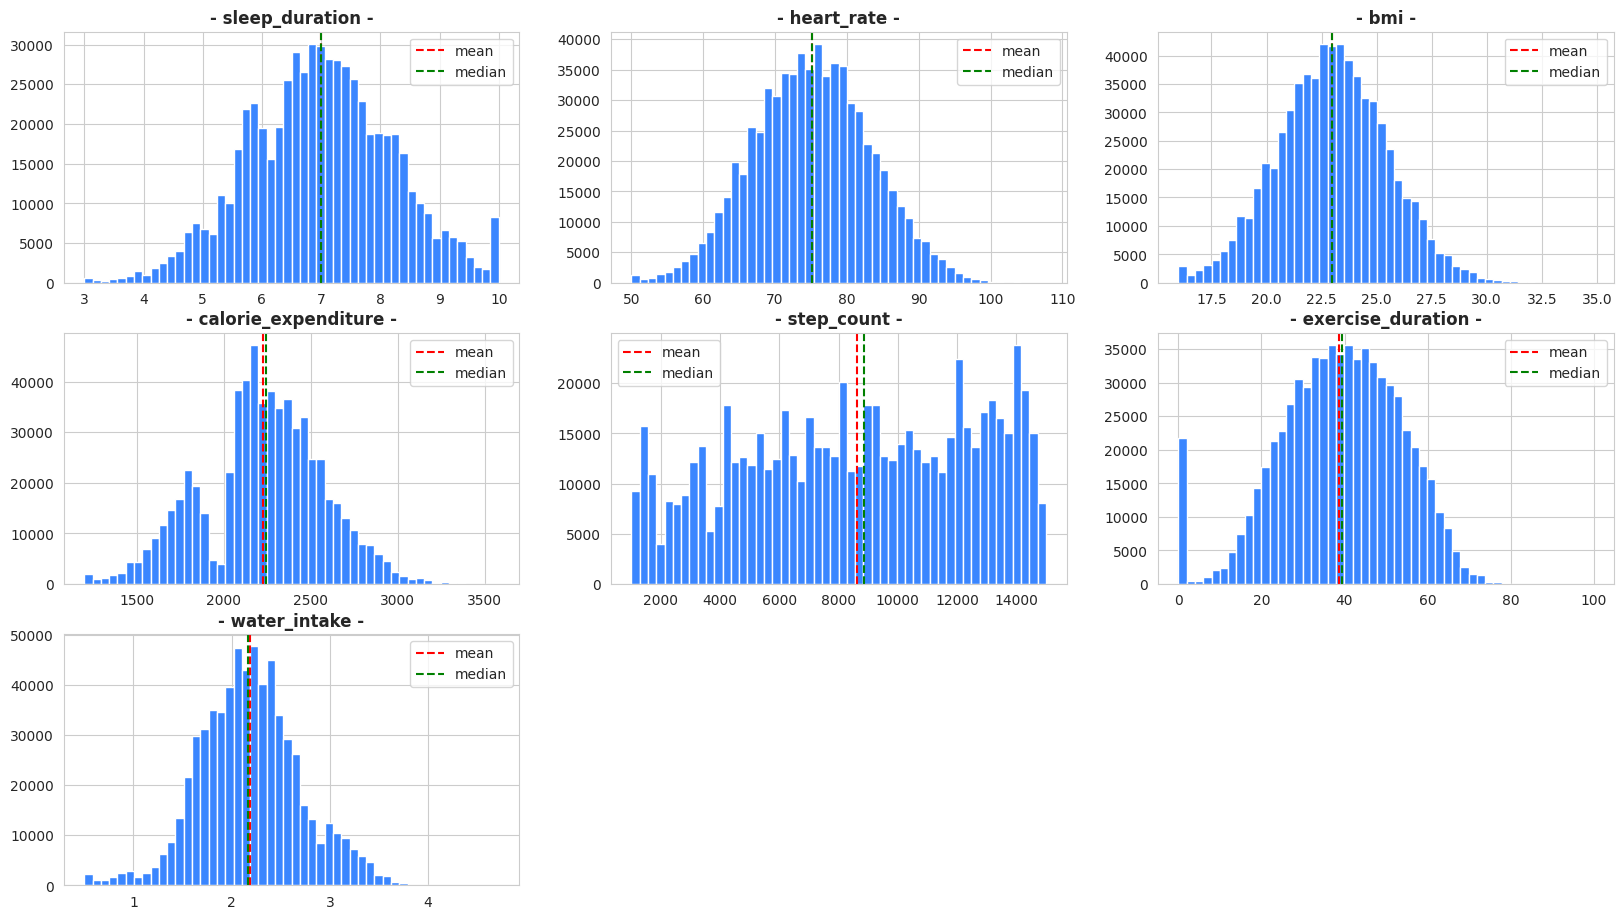

In [8]:
plt.figure(figsize=(20, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='g', linestyle='--', label='median')
    plt.title(f'- {col} -', fontweight='semibold')
    plt.legend()
    
plt.show()

In [9]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
Train,701,537,1596,2101,12807,856,400,3,3,3,3,3,3
Original,700,585,1627,2179,13601,1041,412,3,3,3,3,3,3
Test,692,526,1548,2068,12196,817,392,3,3,3,3,3,3


In [10]:
def get_class_weights(y):
    """
    y: Current y_labels -> array_like or series
    """
    wts_ = compute_class_weight('balanced', classes=np.unique(y), y=y)
    return wts_

def get_sample_weights(y, y_true):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    """
    cls_ = np.unique(y_true)
    wts_ = compute_class_weight('balanced', classes=cls_, y=y_true)
    class_weights = dict(zip(cls_, wts_))
    return np.array([class_weights[label] for label in y])

def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    return balanced_accuracy_score(y_true, pred_labels)

def t_enc_multi(X_tr, X_va, X_ts, y_tr, cols, drop=False):
    X_tr_1 = X_tr.copy()
    X_va_1 = X_va.copy()
    X_ts_1 = X_ts.copy()

    te_enc = TargetEncoder(target_type='multiclass', random_state=CFG['SEED']).set_output(transform='pandas')

    X_tr_te = te_enc.fit_transform(X_tr_1[cols], y_tr)
    X_va_te = te_enc.transform(X_va_1[cols])
    X_ts_te = te_enc.transform(X_ts_1[cols])

    te_names = [f"_TE_{c}" for c in X_tr_te.columns]
    X_tr_1[te_names] = X_tr_te
    X_va_1[te_names] = X_va_te
    X_ts_1[te_names] = X_ts_te

    if drop:
        X_tr_1.drop(columns=cols, inplace=True)
        X_va_1.drop(columns=cols, inplace=True)
        X_ts_1.drop(columns=cols, inplace=True)

    return X_tr_1, X_va_1, X_ts_1

print('- Helper Functions Ready -')

- Helper Functions Ready -


## FEATURE ENGINEERING

In [11]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [12]:
# for col in ['alpha', 'delta', 'redshift']:
#     print(f"\nRounding... ", end='')
#     for r in range(-3, 6):
#         r_n = f"{col}_round_{r}"
#         print(r_n+', ', end='')
#         train[r_n] = train[col].round(r).astype('int32')
#         test[r_n]  = test[col].round(r).astype('int32')
#         orig[r_n]  = orig[col].round(r).astype('int32')
#         ## -- Drop irrelevant features --
#         if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#             DROP_COLS.append(r_n)
#         else:
#             ROUNDS.append(r_n)

#     # print(f"\nDigitizing... ", end='')
#     # for d in range(-3, 7):
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nEqual binning... ", end='')
#     # for b in [32, 64, 128]: # 100, 500, 1000
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nQuantile binning... ", end='')
#     # for q in [32, 64, 128]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ ROUNDS: {len(ROUNDS)}')
# print(f"✅ DIGITS: {len(DIGITS)}")
# print(f"✅ E_BINS: {len(E_BINS)}")
# print(f"✅ Q_BINS: {len(Q_BINS)}")

In [13]:
# for col in ['delta']: # 'u', 'g', 'r', 'i', 'z',
#     # print(f"\nRounding... ", end='')
#     # for r in range(-3, 5):
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')
#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)
    
#     # print(f"\nExtracting digits... ", end='')
#     # for d in range(-3, 6):
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nEqual binning... ", end='')
#     # for b in [100]: # 50, 100, 400
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     # Fit on train data and transform both train and test
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     print(f"\nQuantile binning.. ", end='')
#     for q in [90, 180, 360]: 
#         q_n = f'{col}_qbin_{q}'
#         print(q_n+', ', end='')
#         train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#         test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#         orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#         Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ ROUNDS: {len(ROUNDS)}')
# print(f"✅ DIGITS: {len(DIGITS)}")
# print(f"✅ E_BINS: {len(E_BINS)}")
# print(f"✅ Q_BINS: {len(Q_BINS)}")

In [14]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}\n")

train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

Features dropped: []



Series([], dtype: float64)

In [15]:
# def add_frequency_condition(df1, cols, thresh=5):
#     df = df1.copy()
#     for c in cols:
#         # 1. Get value counts
#         v_counts = df[c].value_counts()
#         # 2. Identify values to replace (count <= threshold)
#         to_replace = v_counts[v_counts <= thresh].index
#         # 3. Apply condition: if value in low-freq list, assign 0, else keep it
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# for df in [train, test, orig]:
#     df = add_frequency_condition(df, DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [16]:
# ## -- Arithmetic interaction --
# BANDS = ['u', 'g', 'r', 'i', 'z']
# COLOR_PAIRS = [
#     ('u', 'g'),
#     ('g', 'r'),
#     ('i', 'z'),
#     ('r', 'z'),
#     ('u', 'z'),
#     ('r', 'i'),
# ]

# for df in tqdm([train, test, orig], desc="Arithmetic features"):
#     for a, b in COLOR_PAIRS:
#         df[f"_{a}_{b}"] = (df[a] - df[b]).astype('float32')

#     for band in ['g', 'i']:
#         df[f"_div_{band}_redshift"] = (df[band] / (df['redshift']+1e-6)).astype('float32')

#     df['_log_redshift'] = np.log1p(df['redshift']).astype('float32')
#     df['_sky_dist'] = np.sqrt(df['alpha']**2 + df['delta']**2)
#     df['_stellar_locus_dist'] = np.sqrt((df['_g_r'] - 0.52)**2 + (df['_r_i'] - 0.25)**2)

#     # df["_mean_bands"] = df[BANDS].mean(axis=1)
#     # df["_std_bands"] = df[BANDS].std(axis=1)
#     # df["_skew_bands"] = df[BANDS].skew(axis=1)
#     # df["_max_bands"] = df[BANDS].max(axis=1)
#     # df["_min_bands"] = df[BANDS].min(axis=1)
#     # df["_range_bands"] = df["_max_bands"] - df["_min_bands"]

In [17]:
# ## -- Cyclic encoding --
# for df in tqdm([train, test, orig], desc="Cyclic features"):
#     for col in ['alpha', 'delta']:
#         for p in [180, 360]:
#             df[f"{col}_sin_{p}"] = np.sin(2 * np.pi * df[col] / p).astype('float32')
#             df[f"{col}_cos_{p}"] = np.cos(2 * np.pi * df[col] / p).astype('float32')

In [18]:
# ## -- Frequency encoding --
# freq_cols = []

# print(f"\nCreate frequencies... ", end='')
# for col in ['spectral_type']:
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_freq'
#     print(n+', ', end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     freq_cols.append(n)

# print()
# print(f"✅ Total frequency features: {len(freq_cols)}")

# train[freq_cols].head()

In [19]:
# INTER = []

# for c1, c2 in tqdm(list(itertools.combinations(CATS, 2)), desc='Pairwise'):
#     n_col = f"_Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(itertools.combinations(TOP_COLS, 3)), desc='Triplewise'):
# #     n_col = f"_Tri_{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# # for c1, c2 in tqdm(list(itertools.product(TOP_COLS, LOW_COLS)), desc='One-to-Many'):
# #     n_col = f"_Bi_{c1}-|-{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print(f"Total interaction features: {len(INTER)}")

# train[INTER].head()

In [20]:
# from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

# class TargetEncoder(BaseEstimator, TransformerMixin):
#     """
#     Target Encoder that supports multiple aggregation functions,
#     internal cross-validation for leakage prevention, and smoothing.

#     Parameters
#     ----------
#     cols_to_encode : list of str
#         List of column names to be target encoded.

#     aggs : list of str, default=['mean']
#         List of aggregation functions to apply. Any function accepted by
#         pandas' `.agg()` method is supported, such as:
#         'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
#         'count', 'sum', 'median'.
#         Smoothing is applied only to the 'mean' aggregation.

#     cv : int, default=5
#         Number of folds for cross-validation in fit_transform.

#     smooth : float or 'auto', default='auto'
#         The smoothing parameter `m`. A larger value puts more weight on the
#         global mean. If 'auto', an empirical Bayes estimate is used.

#     drop_original : bool, default=False
#         If True, the original columns to be encoded are dropped.
#     """
#     def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
#         self.cols_to_encode = cols_to_encode
#         self.aggs = aggs
#         self.cv = cv
#         self.smooth = smooth
#         self.drop_original = drop_original
#         self.mappings_ = {}
#         self.global_stats_ = {}

#     def fit(self, X, y):
#         """
#         Learn mappings from the entire dataset.
#         These mappings are used for the transform method on validation/test data.
#         """
#         temp_df = X.copy()
#         temp_df['target'] = y

#         # Learn global statistics for each aggregation
#         for agg_func in self.aggs:
#             self.global_stats_[agg_func] = y.agg(agg_func)

#         # Learn category-specific mappings
#         for col in self.cols_to_encode:
#             self.mappings_[col] = {}
#             for agg_func in self.aggs:
#                 mapping = temp_df.groupby(col)['target'].agg(agg_func)
#                 self.mappings_[col][agg_func] = mapping

#         return self

#     def transform(self, X):
#         """
#         Apply learned mappings to the data.
#         Unseen categories are filled with global statistics.
#         """
#         X_transformed = X.copy()
#         for col in self.cols_to_encode:
#             for agg_func in self.aggs:
#                 new_col_name = f'TE_{col}_{agg_func}'
#                 map_series = self.mappings_[col][agg_func]
#                 X_transformed[new_col_name] = X[col].map(map_series)
#                 X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

#         if self.drop_original:
#             X_transformed.drop(columns=self.cols_to_encode, inplace=True)

#         return X_transformed

#     def fit_transform(self, X, y):
#         """
#         Fit and transform the data using internal cross-validation to prevent leakage.
#         """
#         # First, fit on the entire dataset to get global mappings for transform method
#         self.fit(X, y)

#         # Initialize an empty DataFrame to store encoded features
#         encoded_features = pd.DataFrame(index=X.index)

#         kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

#         for train_idx, val_idx in kf.split(X, y):
#             X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
#             X_val = X.iloc[val_idx]

#             temp_df_train = X_train.copy()
#             temp_df_train['target'] = y_train

#             for col in self.cols_to_encode:
#                 # --- Calculate mappings only on the training part of the fold ---
#                 for agg_func in self.aggs:
#                     new_col_name = f'TE_{col}_{agg_func}'

#                     # Calculate global stat for this fold
#                     fold_global_stat = y_train.agg(agg_func)

#                     # Calculate category stats for this fold
#                     mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

#                     # --- Apply smoothing only for 'mean' aggregation ---
#                     if agg_func == 'mean':
#                         counts = temp_df_train.groupby(col)['target'].count()

#                         m = self.smooth
#                         if self.smooth == 'auto':
#                             # Empirical Bayes smoothing
#                             variance_between = mapping.var()
#                             avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
#                             if variance_between > 0:
#                                 m = avg_variance_within / variance_between
#                             else:
#                                 m = 0  # No smoothing if no variance between groups

#                         # Apply smoothing formula
#                         smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
#                         encoded_values = X_val[col].map(smoothed_mapping)
#                     else:
#                         encoded_values = X_val[col].map(mapping)

#                     # Store encoded values for the validation fold
#                     encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

#         # Merge with original DataFrame
#         X_transformed = X.copy()
#         for col in encoded_features.columns:
#             X_transformed[col] = encoded_features[col]

#         if self.drop_original:
#             X_transformed.drop(columns=self.cols_to_encode, inplace=True)

#         return X_transformed


# class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
#     def __init__(self, cat_cols=None):
#         self.cat_cols = cat_cols
#         self.mappings_ = {}
#     def fit(self, X, y):
#         X = X.copy()
#         if self.cat_cols is None:
#             self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
#         self.mappings_ = {}
#         for col in self.cat_cols:
#             df_temp = pd.DataFrame({col: X[col], 'y': y})
#             group_means = df_temp.groupby(col, dropna=False)['y'].mean()
#             sorted_categories = group_means.sort_values().index
#             self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
#         return self

#     def transform(self, X, y=None):
#         X = X.copy()
#         for col, mapping in self.mappings_.items():
#             if col in X.columns:
#                 X[col] = X[col].map(mapping)
#         return X

In [21]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [22]:
# train, test, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE+ROUNDS,
#     target=TARGET,
#     aggs=['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
#     fill_nan=True,
# )

In [23]:
# ## -- Duplicate all numerics as categories --
# CATS_2 = []

# for c in NUMS:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     orig[n]  = orig[c].copy()
#     CATS_2.append(n)

#     ## -- FACTORIZE CATS_2 --
#     combine  = pd.concat([train[n], test[n], orig[n]])
#     v = combine.factorize()[0]
#     train[n] = v[:len(train)].astype('int32')
#     test[n]  = v[len(train):len(train)+len(test)].astype('int32')
#     orig[n]  = v[len(train)+len(test):].astype('int32')

# print(f'Numericals to Categoricals: {len(CATS_2)}')

In [24]:
# ## -- Factorize using combined data --
# for c in CATS:
#     combine  = pd.concat([train[c], test[c], orig[c]])
#     combine  = combine.factorize()[0]
#     # combine  = pd.Series(combine).astype('category')
#     train[c] = combine[:len(train)]
#     test[c]  = combine[len(train):len(train)+len(test)]
#     orig[c]  = combine[len(train)+len(test):]

# print('Label encoding complete!')

In [25]:
## -- Get NaN indicators --
def appy_nan_indicator(df):
    df1 = df.copy()
    cols_with_nan = df1.columns[df1.isna().any()]
    indicators = df1[cols_with_nan].isna().astype(float).add_prefix('isna_')
    indi_cols = indicators.columns.tolist()
    df1 = df1.join(indicators)

    return df1, indi_cols

train, INDI_COLS = appy_nan_indicator(train)
test, _  = appy_nan_indicator(test)
orig, _  = appy_nan_indicator(orig)

## -- Fill categorical --
train[CATS] = train[CATS].fillna('missing')
test[CATS]  = test[CATS].fillna('missing')
orig[CATS]  = orig[CATS].fillna('missing')

print(INDI_COLS)
train

['isna_sleep_duration', 'isna_heart_rate', 'isna_bmi', 'isna_calorie_expenditure', 'isna_step_count', 'isna_exercise_duration', 'isna_water_intake', 'isna_diet_type', 'isna_stress_level', 'isna_sleep_quality', 'isna_physical_activity_level', 'isna_smoking_alcohol', 'isna_gender']


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,isna_sleep_duration,isna_heart_rate,isna_bmi,isna_calorie_expenditure,isna_step_count,isna_exercise_duration,isna_water_intake,isna_diet_type,isna_stress_level,isna_sleep_quality,isna_physical_activity_level,isna_smoking_alcohol,isna_gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,missing,average,sedentary,missing,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,690083,at-risk,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
690084,690084,at-risk,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
690085,690085,fit,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,missing,average,active,no,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
690086,690086,at-risk,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,missing,average,active,yes,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [26]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print('Total Features:', len(FEATURES))

train

Total Features: 26


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,isna_sleep_duration,isna_heart_rate,isna_bmi,isna_calorie_expenditure,isna_step_count,isna_exercise_duration,isna_water_intake,isna_diet_type,isna_stress_level,isna_sleep_quality,isna_physical_activity_level,isna_smoking_alcohol,isna_gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,missing,average,sedentary,missing,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,690083,at-risk,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
690084,690084,at-risk,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
690085,690085,fit,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,missing,average,active,no,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
690086,690086,at-risk,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,missing,average,active,yes,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


# ML TRAINING

In [27]:
combined = pd.concat([train[FEATURES], test[FEATURES]])
new_features = combined.columns.tolist()
categorical_dims = { col: combined[col].nunique() for col in CATS+INDI_COLS }

cat_in_features = [ f for f in CATS+INDI_COLS if f in new_features ]
cat_idxs = [ new_features.index(f) for f in cat_in_features ]
cat_dims = [ categorical_dims[f] for f in new_features if f in cat_in_features ]

print(cat_idxs, cat_dims)

del combined

[7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25] [4, 4, 4, 4, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [28]:
def Trainer_CV(
    model_name, params, train_df, test_df, features, target, kfold, metrics=['log_loss'],
    process_skrub=True, cat_cols=None, num_cols=None, show_df=False,
    ):

    print(f"\n===== Starting CV: {model_name} =====")
    start = time()

    X = train_df[features] 
    y = train_df[target].map(mapping)

    num_cls = y.nunique()
    
    oof_preds  = np.zeros((len(X), num_cls))
    test_preds = np.zeros((len(test_df), num_cls))

    fold_scores  = []
    brier_scores = []
    feat_importances = []

    for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
        print(f"\n ##### FOLD {idx}/{kfold.n_splits} | ", end='')

        # Split data for the current fold
        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test_df[features].copy()

        # ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
        # y_train = pd.concat([y_train, orig[TARGET]], ignore_index=True)
        # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        # print(f" • Target Encoding {len(te_cols)} features... ")
        # X_train, X_valid, X_test = t_enc_multi(X_train, X_valid, X_test, y_train, ROUNDS, drop=True)

        for col in num_cols:
            scaler = StandardScaler()
            X_train[col] = scaler.fit_transform(X_train[[col]])
            X_test[col]  = scaler.transform(X_test[[col]])
            X_valid[col] = scaler.transform(X_valid[[col]])

            imputer = IterativeImputer(max_iter=50, tol=1e-5, random_state=0)
            X_train[col] = imputer.fit_transform(X_train[[col]])
            X_valid[col] = imputer.transform(X_valid[[col]])
            X_test[col]  = imputer.transform(X_test[[col]])

        ## OPTION_1: =====================================================================
        if process_skrub:
            print("Skrub processing... | ", end='')
            tabvec  = skrub.TableVectorizer(n_jobs=-1)
            X_train = tabvec.fit_transform(X_train, y_train)
            X_valid = tabvec.transform(X_valid)
            X_test  = tabvec.transform(X_test)

            print(f"X_train shape: {X_train.shape} #####")
            model = TabNetClassifier(**params)
        else:
            ## -- Define cat features for cat embeddings --
            print("TabNet embedding processing... | ", end='')
            combined = pd.concat([X_train, X_valid, X_test])

            for col in cat_cols:
                l_enc = LabelEncoder()
                l_enc.fit(combined[col].astype(str))

                X_train[col] = l_enc.transform(X_train[col].astype(str))
                X_valid[col] = l_enc.transform(X_valid[col].astype(str))
                X_test[col]  = l_enc.transform(X_test[col].astype(str))

            new_features = combined.columns.tolist()
            categorical_dims = { col: combined[col].nunique() for col in cat_cols }

            cat_in_features = [ f for f in cat_cols if f in new_features ]
            cat_idxs = [ new_features.index(f) for f in cat_in_features ]
            cat_dims = [ categorical_dims[f] for f in new_features if f in cat_in_features ]

            print(f"X_train shape: {X_train.shape}")
            print()
            print('cat_idxs:', cat_idxs)
            print('cat_dims:', cat_dims)

            model = TabNetClassifier(**params, cat_idxs=cat_idxs, cat_dims=cat_dims)

        if show_df:
            display(X_train.head(3))

        model.fit(
            X_train.to_numpy(), y_train.to_numpy(),
            eval_set=[(X_valid.to_numpy(), y_valid.to_numpy())],
            max_epochs=200,
            patience=10,
            eval_metric=metrics,
            weights=get_sample_weights(y_train, y_train),
            # batch_size=2048,
            # virtual_batch_size=512,
            drop_last=False,
        )

        ## -- Predict on validation and test sets --
        oof_preds[val_idx] = model.predict_proba(X_valid.to_numpy())
        test_preds += model.predict_proba(X_test.to_numpy()) / kfold.n_splits

        ## -- Calculate and print fold score --
        fold_score = balanced_acc(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f"{CFG['YELLOW']}• Fold {idx} score: {fold_score:.5f} {CFG['RESET']}")

        ## -- Clean up memory --
        torch.cuda.empty_cache()

    ## -- Print final cross-validation results --
    print("\n==================================================")
    print(f"{CFG['FOLDS']}-FOLD CV: {model_name}")
    print("==================================================")
    for i, score in enumerate(fold_scores, 1):
        print(f" • Fold {i} score: {score:.5f}")

    ## -- Final out-of-fold --
    oof_score = np.round(balanced_acc(y, oof_preds), 5)
    print("-------------------------------------------------|")
    print(f"OOF score: {oof_score}")
    print(f"AVG score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print("-------------------------------------------------|")
    print(f'{((time() - start) / 60):.2f} mins\n')

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'scores': oof_score,
        'model': model,
        'val_data': X_valid,
        'columns': X_valid.columns.tolist(),
    }

print("⚙️ Training function ready ⚙️")

⚙️ Training function ready ⚙️


In [29]:
# def Trainer_CV(
#     model_name, params, train_df, test_df, features, target, kfold, metrics=['log_loss'],
#     process_skrub=True, cat_cols=None, num_cols=None, show_df=False,
#     ):

#     print(f"\n===== Starting CV: {model_name} =====")
#     start = time()

#     X = train_df[features]
#     y = train_df[target].map(mapping)

#     num_cls = y.nunique()
    
#     oof_preds = np.zeros((len(X), num_cls))
#     test_preds = np.zeros((len(test_df), num_cls))

#     fold_scores = []
#     brier_scores = []
#     feat_importances = []

#     for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
#         print(f"\n ##### FOLD {idx}/{kfold.n_splits} | ", end='')

#         # Split data for the current fold
#         X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
#         y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
#         X_test = test_df[features].copy()

#         # ## -- OPTION A: Concatenate original data --
#         # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
#         # y_train = pd.concat([y_train, orig[TARGET]], ignore_index=True)
#         # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

#         # print(f" • Target Encoding {len(te_cols)} features... ")
#         # X_train, X_valid, X_test = t_enc_multi(X_train, X_valid, X_test, y_train, ROUNDS, drop=True)

#         ## -- Handle missing data --
#         for col in num_cols:
#             estimator = HistGradientBoostingRegressor(random_state=CFG['SEED'], tol=1e-5)
#             imputer = IterativeImputer(estimator, max_iter=20, tol=1e-5, random_state=0)
#             X_train[col] = imputer.fit_transform(X_train[[col]])
#             X_valid[col] = imputer.transform(X_valid[[col]])
#             X_test[col]  = imputer.transform(X_test[[col]])

#         # for col in num_cols:
#         #     scaler = StandardScaler()
#         #     X_train[col] = scaler.fit_transform(X_train[[col]])
#         #     X_test[col]  = scaler.transform(X_test[[col]])
#         #     X_valid[col] = scaler.transform(X_valid[[col]])

#         ## OPTION_1: =====================================================================
#         if process_skrub:
#             print("Skrub processing... | ", end='')
#             tabvec  = skrub.TableVectorizer(n_jobs=-1) # 
#             X_train = tabvec.fit_transform(X_train, y_train)
#             X_valid = tabvec.transform(X_valid)
#             X_test  = tabvec.transform(X_test)

#             print(f"X_train shape: {X_train.shape} #####")
#             model = TabNetClassifier(**params)
#         else:
#             # ## -- Scale data --
#             # for col in num_cols:
#             #     scaler = StandardScaler()
#             #     X_train[col] = scaler.fit_transform(X_train[[col]])
#             #     X_test[col]  = scaler.transform(X_test[[col]])
#             #     X_valid[col] = scaler.transform(X_valid[[col]])

#             ## -- Define cat features for cat embeddings --
#             print("TabNet embedding processing... | ", end='')
#             combined = pd.concat([X_train, X_valid, X_test])

#             if cat_cols is not None:
#                 for col in cat_cols:
#                     l_enc = LabelEncoder()
#                     l_enc.fit(combined[col].astype(str))
            
#                     X_train[col] = l_enc.transform(X_train[col].astype(str))
#                     X_valid[col] = l_enc.transform(X_valid[col].astype(str))
#                     X_test[col]  = l_enc.transform(X_test[col].astype(str))

#             new_features = combined.columns.tolist()
#             categorical_dims = { col: combined[col].nunique() for col in cat_cols }
        
#             cat_cols_in_features = [ f for f in cat_cols if f in new_features ]
#             cat_idxs = [ new_features.index(f) for f in cat_cols ]
#             cat_dims = [ categorical_dims[f] for f in new_features if f in cat_cols ]
    
#             print(f"X_train shape: {X_train.shape} ###")
#             print()
#             print('cat_idxs:', cat_idxs)
#             print('cat_dims:', cat_dims)
            
#             model = TabNetClassifier(**params, cat_idxs=cat_idxs, cat_dims=cat_dims)

#         if show_df:
#             display(X_train.head(3))

#         model.fit(
#             X_train.to_numpy(), y_train.to_numpy(),
#             eval_set=[(X_valid.to_numpy(), y_valid.to_numpy())],
#             max_epochs=30,
#             patience=5,
#             eval_metric=metrics,
#             weights=get_sample_weights(y_train, y_train),
#             # batch_size=2048,
#             # virtual_batch_size=512,
#         )

#         ## -- Predict on validation and test sets --
#         oof_preds[val_idx] = model.predict_proba(X_valid.to_numpy())
#         test_preds += model.predict_proba(X_test.to_numpy()) / kfold.n_splits

#         ## -- Calculate and print fold score --
#         fold_score = balanced_acc(y_valid, oof_preds[val_idx])
#         fold_scores.append(fold_score)
#         print(f"{CFG['YELLOW']}• Fold {idx} score: {fold_score:.5f} {CFG['RESET']}")

#         ## -- Clean up memory --
#         torch.cuda.empty_cache()

#     ## -- Print final cross-validation results --
#     print("\n==================================================")
#     print(f"{CFG['FOLDS']}-FOLD CV: {model_name}")
#     print("==================================================")
#     for i, score in enumerate(fold_scores, 1):
#         print(f" • Fold {i} score: {score:.5f}")

#     ## -- Final out-of-fold --
#     oof_score = np.round(balanced_acc(y, oof_preds), 5)
#     print("-------------------------------------------------|")
#     print(f"OOF score: {oof_score}")
#     print(f"AVG score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
#     print("-------------------------------------------------|")
#     print(f'{((time() - start) / 60):.2f} mins\n')

#     return {
#         'oof_preds': oof_preds,
#         'test_preds': test_preds,
#         'scores': oof_score,
#         'model': model,
#         'val_data': X_valid,
#         'columns': X_valid.columns.tolist(),
#     }

# print("⚙️ Training function ready ⚙️")

In [30]:
all_predictions = {}

USE_FULL_TRAIN  = True
USE_CALIBRATION = False

CFG['FOLDS'] = 5
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)

train_data = train.copy() if USE_FULL_TRAIN else x_sample.copy()
train_data

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,isna_sleep_duration,isna_heart_rate,isna_bmi,isna_calorie_expenditure,isna_step_count,isna_exercise_duration,isna_water_intake,isna_diet_type,isna_stress_level,isna_sleep_quality,isna_physical_activity_level,isna_smoking_alcohol,isna_gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,missing,average,sedentary,missing,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,690083,at-risk,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
690084,690084,at-risk,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
690085,690085,fit,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,missing,average,active,no,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
690086,690086,at-risk,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,missing,average,active,yes,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [31]:
# if all_predictions:
#     all_predictions.clear()

PARAMS = {
    'n_d': 6, # 8*2
    'n_a': 6, # 8*2
    # 'n_steps': 3,
    # 'gamma': 1.3,
    # 'n_independent': 2,
    # 'n_shared': 2,
    # 'epsilon': 1e-15,
    # 'lambda_sparse': 1e-3,
    # 'cat_emb_dim': 2,
    # 'mask_type': 'sparsemax',
    'optimizer_fn': torch.optim.Adam,
    'optimizer_params': {'lr': 0.01, 'weight_decay': 0.0},
    # 'scheduler_fn': torch.optim.lr_scheduler.StepLR,
    # 'scheduler_params': {'step_size': 20, 'gamma': 0.9},
    'verbose': 1,
    'seed': CFG['SEED'],
}

## ----------------------------------------------
n = 'tabnet'
# for VALUE in [False]: 
#     # PARAMS['n_d'] = VALUE
#     # PARAMS['n_a'] = VALUE
#     n = f"{VERS}_{str(VALUE)}"
all_predictions[n] = Trainer_CV(
    model_name=n,
    params=PARAMS,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    metrics=['balanced_accuracy'],
    process_skrub=False,
    cat_cols=CATS+INDI_COLS,
    num_cols=NUMS,
    show_df=True,
)

## ----------------------------------------------
n = 'tabnet_vec'
all_predictions[n] = Trainer_CV(
    model_name=n,
    params=PARAMS,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    metrics=['balanced_accuracy'],
    process_skrub=True,
    cat_cols=CATS+INDI_COLS,
    num_cols=NUMS,
    show_df=True,
)


===== Starting CV: tabnet =====

 ##### FOLD 1/5 | TabNet embedding processing... | X_train shape: (552070, 26)

cat_idxs: [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
cat_dims: [4, 4, 4, 4, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,isna_sleep_duration,isna_heart_rate,isna_bmi,isna_calorie_expenditure,isna_step_count,isna_exercise_duration,isna_water_intake,isna_diet_type,isna_stress_level,isna_sleep_quality,isna_physical_activity_level,isna_smoking_alcohol,isna_gender
1,-1.203345,-0.464810,1.149361,-0.748569,0.323952,0.756476,-1.789720,2,1,0,2,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0
2,-1.400836,0.036831,0.625384,1.328214,1.424641,-0.043360,-1.134287,3,0,3,0,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,-1.886337,0.257064,0.057070,1.161381,-0.367509,1.434304,-0.324635,3,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0


epoch 0  | loss: 0.33462 | val_0_balanced_accuracy: 0.9413  |  0:00:22s
epoch 1  | loss: 0.22764 | val_0_balanced_accuracy: 0.94095 |  0:00:44s
epoch 2  | loss: 0.21695 | val_0_balanced_accuracy: 0.94214 |  0:01:05s
epoch 3  | loss: 0.20804 | val_0_balanced_accuracy: 0.94342 |  0:01:27s
epoch 4  | loss: 0.20734 | val_0_balanced_accuracy: 0.94246 |  0:01:49s
epoch 5  | loss: 0.20904 | val_0_balanced_accuracy: 0.94262 |  0:02:11s
epoch 6  | loss: 0.20494 | val_0_balanced_accuracy: 0.94431 |  0:02:33s
epoch 7  | loss: 0.20086 | val_0_balanced_accuracy: 0.94619 |  0:02:55s
epoch 8  | loss: 0.1986  | val_0_balanced_accuracy: 0.94544 |  0:03:18s
epoch 9  | loss: 0.19655 | val_0_balanced_accuracy: 0.94341 |  0:03:40s
epoch 10 | loss: 0.196   | val_0_balanced_accuracy: 0.94579 |  0:04:02s
epoch 11 | loss: 0.19624 | val_0_balanced_accuracy: 0.94583 |  0:04:24s
epoch 12 | loss: 0.19563 | val_0_balanced_accuracy: 0.94468 |  0:04:46s
epoch 13 | loss: 0.19541 | val_0_balanced_accuracy: 0.94608 |  0

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,isna_sleep_duration,isna_heart_rate,isna_bmi,isna_calorie_expenditure,isna_step_count,isna_exercise_duration,isna_water_intake,isna_diet_type,isna_stress_level,isna_sleep_quality,isna_physical_activity_level,isna_smoking_alcohol,isna_gender
0,-1.458231,-0.550666,1.078287,-0.149930,-1.855635,-1.286436,-0.634442,3,0,0,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,-1.400637,0.036703,0.626999,1.329202,1.425168,-0.044827,-1.136448,3,0,3,0,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,-1.886069,0.256966,0.058858,1.162296,-0.367184,1.434248,-0.325515,3,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0


epoch 0  | loss: 0.33992 | val_0_balanced_accuracy: 0.93947 |  0:00:22s
epoch 1  | loss: 0.21502 | val_0_balanced_accuracy: 0.94318 |  0:00:45s
epoch 2  | loss: 0.20704 | val_0_balanced_accuracy: 0.94509 |  0:01:07s
epoch 3  | loss: 0.19991 | val_0_balanced_accuracy: 0.94637 |  0:01:30s
epoch 4  | loss: 0.19608 | val_0_balanced_accuracy: 0.94636 |  0:01:52s
epoch 5  | loss: 0.19449 | val_0_balanced_accuracy: 0.9482  |  0:02:14s
epoch 6  | loss: 0.19053 | val_0_balanced_accuracy: 0.94868 |  0:02:36s
epoch 7  | loss: 0.18907 | val_0_balanced_accuracy: 0.94796 |  0:02:58s
epoch 8  | loss: 0.18977 | val_0_balanced_accuracy: 0.94744 |  0:03:20s
epoch 9  | loss: 0.18733 | val_0_balanced_accuracy: 0.94905 |  0:03:43s
epoch 10 | loss: 0.18651 | val_0_balanced_accuracy: 0.94923 |  0:04:06s
epoch 11 | loss: 0.18411 | val_0_balanced_accuracy: 0.94877 |  0:04:28s
epoch 12 | loss: 0.1856  | val_0_balanced_accuracy: 0.94862 |  0:04:50s
epoch 13 | loss: 0.18479 | val_0_balanced_accuracy: 0.94834 |  0

...

epoch 0  | loss: 0.33494 | val_0_balanced_accuracy: 0.93267 |  0:00:21s
epoch 1  | loss: 0.22824 | val_0_balanced_accuracy: 0.93329 |  0:00:42s
epoch 2  | loss: 0.21215 | val_0_balanced_accuracy: 0.94326 |  0:01:04s
epoch 3  | loss: 0.19798 | val_0_balanced_accuracy: 0.94372 |  0:01:25s
epoch 4  | loss: 0.20162 | val_0_balanced_accuracy: 0.94285 |  0:01:47s
epoch 5  | loss: 0.19946 | val_0_balanced_accuracy: 0.9445  |  0:02:08s
epoch 6  | loss: 0.19552 | val_0_balanced_accuracy: 0.9445  |  0:02:29s
epoch 7  | loss: 0.19345 | val_0_balanced_accuracy: 0.94496 |  0:02:50s
epoch 8  | loss: 0.19298 | val_0_balanced_accuracy: 0.94547 |  0:03:12s
epoch 9  | loss: 0.19033 | val_0_balanced_accuracy: 0.94385 |  0:03:33s
epoch 10 | loss: 0.19024 | val_0_balanced_accuracy: 0.94466 |  0:03:55s
epoch 11 | loss: 0.18887 | val_0_balanced_accuracy: 0.94618 |  0:04:17s
epoch 12 | loss: 0.18711 | val_0_balanced_accuracy: 0.94491 |  0:04:38s
epoch 13 | loss: 0.18454 | val_0_balanced_accuracy: 0.94667 |  0

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type_balanced,diet_type_missing,diet_type_non-veg,diet_type_veg,stress_level_high,stress_level_low,stress_level_medium,stress_level_missing,sleep_quality_average,sleep_quality_good,sleep_quality_missing,sleep_quality_poor,physical_activity_level_active,physical_activity_level_missing,physical_activity_level_moderate,physical_activity_level_sedentary,smoking_alcohol_missing,smoking_alcohol_no,smoking_alcohol_occasional,smoking_alcohol_yes,gender_female,gender_male,gender_missing,gender_other,isna_sleep_duration,isna_heart_rate,isna_bmi,isna_calorie_expenditure,isna_step_count,isna_exercise_duration,isna_water_intake,isna_diet_type,isna_stress_level,isna_sleep_quality,isna_physical_activity_level,isna_smoking_alcohol,isna_gender
0,-1.459350,-0.548501,1.077929,-0.149754,-1.856188,-1.286079,-0.632531,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-1.204369,-0.462904,1.150439,-0.747995,0.323916,0.756288,-1.788480,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1.401774,0.038450,0.626756,1.328591,1.424786,-0.044374,-1.133442,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


epoch 0  | loss: 0.34889 | val_0_balanced_accuracy: 0.93233 |  0:00:21s
epoch 1  | loss: 0.22475 | val_0_balanced_accuracy: 0.94109 |  0:00:43s
epoch 2  | loss: 0.2096  | val_0_balanced_accuracy: 0.94324 |  0:01:04s
epoch 3  | loss: 0.20576 | val_0_balanced_accuracy: 0.94309 |  0:01:26s
epoch 4  | loss: 0.20115 | val_0_balanced_accuracy: 0.94431 |  0:01:47s
epoch 5  | loss: 0.19959 | val_0_balanced_accuracy: 0.94325 |  0:02:08s
epoch 6  | loss: 0.19826 | val_0_balanced_accuracy: 0.94412 |  0:02:29s
epoch 7  | loss: 0.19877 | val_0_balanced_accuracy: 0.94431 |  0:02:50s
epoch 8  | loss: 0.19575 | val_0_balanced_accuracy: 0.94501 |  0:03:11s
epoch 9  | loss: 0.19128 | val_0_balanced_accuracy: 0.93304 |  0:03:33s
epoch 10 | loss: 0.18776 | val_0_balanced_accuracy: 0.94592 |  0:03:54s
epoch 11 | loss: 0.18662 | val_0_balanced_accuracy: 0.94692 |  0:04:15s
epoch 12 | loss: 0.18418 | val_0_balanced_accuracy: 0.94735 |  0:04:37s
epoch 13 | loss: 0.1856  | val_0_balanced_accuracy: 0.94665 |  0

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type_balanced,diet_type_missing,diet_type_non-veg,diet_type_veg,stress_level_high,stress_level_low,stress_level_medium,stress_level_missing,sleep_quality_average,sleep_quality_good,sleep_quality_missing,sleep_quality_poor,physical_activity_level_active,physical_activity_level_missing,physical_activity_level_moderate,physical_activity_level_sedentary,smoking_alcohol_missing,smoking_alcohol_no,smoking_alcohol_occasional,smoking_alcohol_yes,gender_female,gender_male,gender_missing,gender_other,isna_sleep_duration,isna_heart_rate,isna_bmi,isna_calorie_expenditure,isna_step_count,isna_exercise_duration,isna_water_intake,isna_diet_type,isna_stress_level,isna_sleep_quality,isna_physical_activity_level,isna_smoking_alcohol,isna_gender
0,-1.459015,-0.550109,1.078502,-0.149028,-1.853898,-1.285229,-0.634266,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-1.203860,-0.464494,1.151041,-0.747673,0.325673,0.756730,-1.791613,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-1.887017,0.257123,0.058929,1.163386,-0.365734,1.435122,-0.325640,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


epoch 0  | loss: 0.34993 | val_0_balanced_accuracy: 0.93765 |  0:00:20s
epoch 1  | loss: 0.21109 | val_0_balanced_accuracy: 0.94099 |  0:00:42s
epoch 2  | loss: 0.20399 | val_0_balanced_accuracy: 0.94126 |  0:01:03s
epoch 3  | loss: 0.19869 | val_0_balanced_accuracy: 0.94284 |  0:01:24s
epoch 4  | loss: 0.19709 | val_0_balanced_accuracy: 0.94222 |  0:01:45s
epoch 5  | loss: 0.19614 | val_0_balanced_accuracy: 0.9424  |  0:02:06s
epoch 6  | loss: 0.19262 | val_0_balanced_accuracy: 0.94408 |  0:02:27s
epoch 7  | loss: 0.19227 | val_0_balanced_accuracy: 0.94335 |  0:02:48s
epoch 8  | loss: 0.1891  | val_0_balanced_accuracy: 0.94364 |  0:03:10s
epoch 9  | loss: 0.1891  | val_0_balanced_accuracy: 0.94295 |  0:03:31s
epoch 10 | loss: 0.18809 | val_0_balanced_accuracy: 0.94486 |  0:03:51s
epoch 11 | loss: 0.18579 | val_0_balanced_accuracy: 0.94526 |  0:04:12s
epoch 12 | loss: 0.18665 | val_0_balanced_accuracy: 0.94502 |  0:04:33s
epoch 13 | loss: 0.18459 | val_0_balanced_accuracy: 0.9454  |  0

In [32]:
# 5-FOLD CV: tabnet_CPU
# ==================================================
# OOF score: 0.94264
# AVG score: 0.94264 ± 0.00271
# -------------------------------------------------|
# 15.21 mins

# ==================================================
# 5-FOLD CV: tabnet_GPU
# ==================================================
# OOF score: 0.9421
# AVG score: 0.94210 ± 0.00302
# -------------------------------------------------|
# 12.00 mins

## ========================

# 5-FOLD CV: tabnet_vec_CPU
# ==================================================
# OOF score: 0.94278
# AVG score: 0.94278 ± 0.00300
# -------------------------------------------------|
# 17.88 mins

# ==================================================
# 5-FOLD CV: tabnet_vec_GPU
# ==================================================
# OOF score: 0.94365
# AVG score: 0.94365 ± 0.00216
# -------------------------------------------------|
# 16.59 mins

In [33]:
# !rm -r /kaggle/working

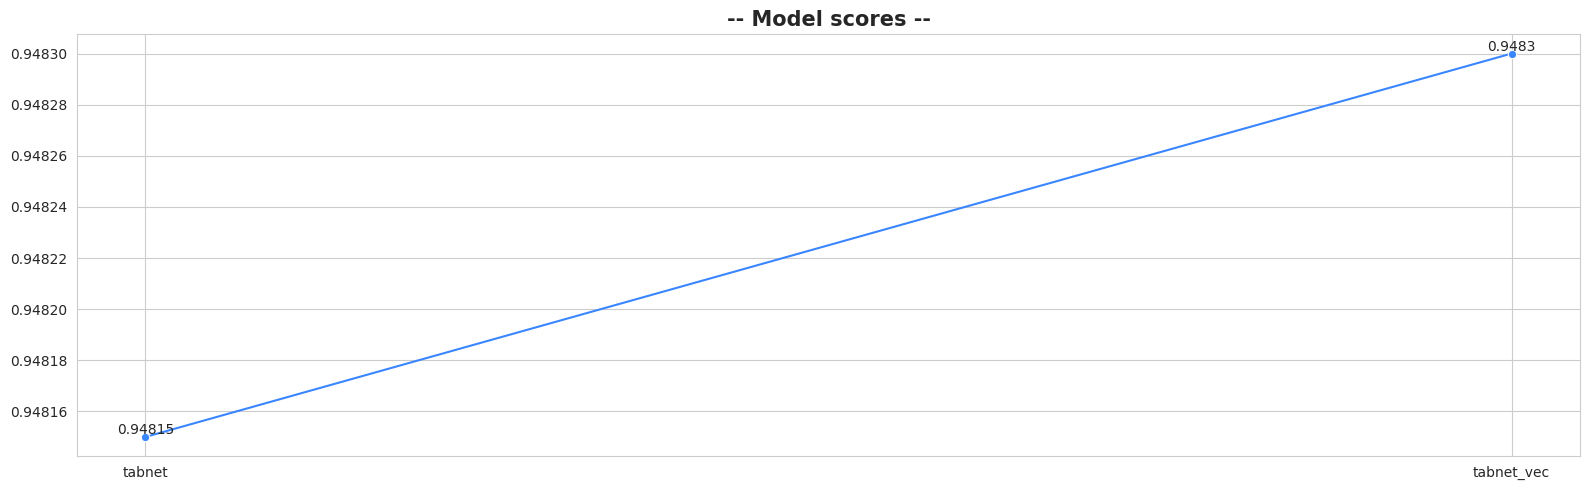

In [34]:
## -- Get model scores --
all_scores = {}

for k, v in all_predictions.items():
    for x, y in v.items():
        if x == 'scores':
            all_scores[k] = y

plt.figure(figsize=(16, 5))
ax = sns.lineplot(all_scores, marker='o')

# ax.fill_between(range(len(all_scores)), all_scores.values(), alpha=0.3)
ax.set_title("-- Model scores --", fontsize=15, fontweight='semibold')
ax.tick_params('x', rotation=0)

add_ = 1e-6
for i, s in enumerate(all_scores.values()):
    ax.text(float(i), s+add_, s, ha='center', va='baseline')

# ax.set_ylim(0.94, 0.97)
plt.tight_layout()
plt.show()

tabnet_94815 saved!


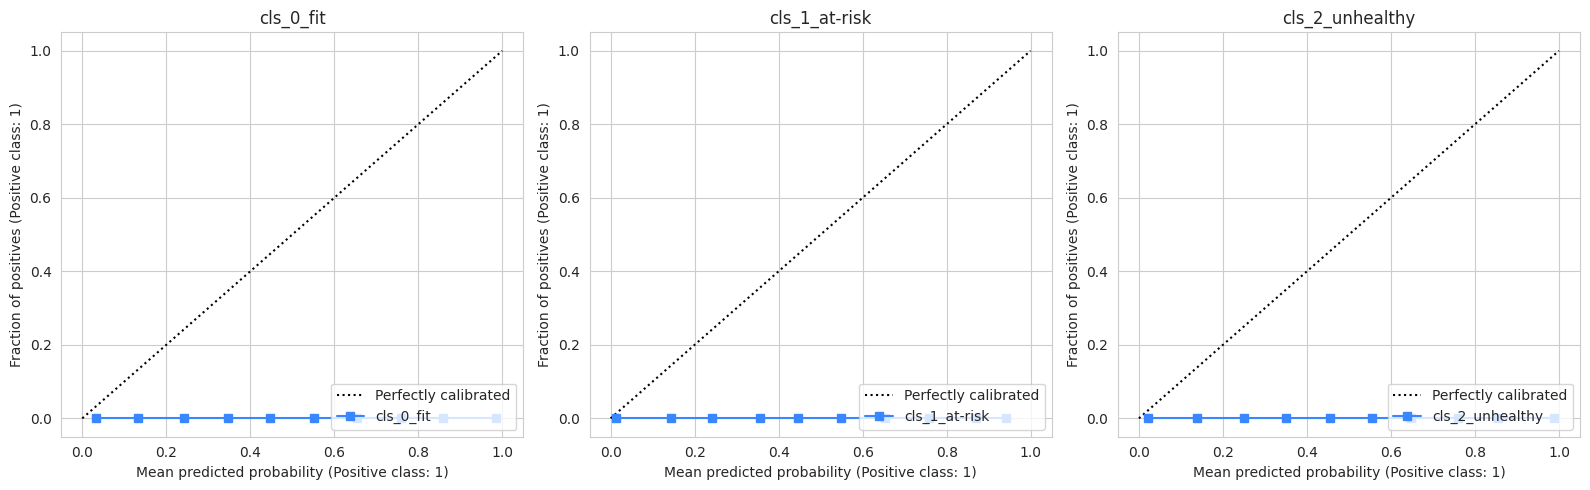

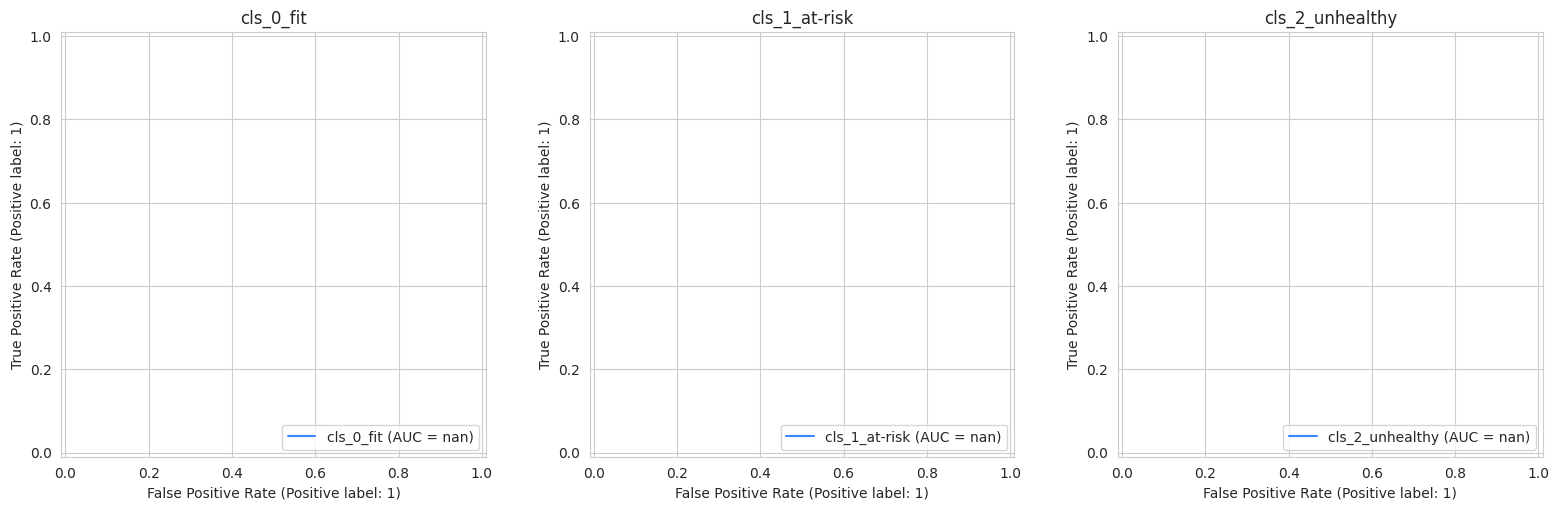


tabnet_vec_9483 saved!


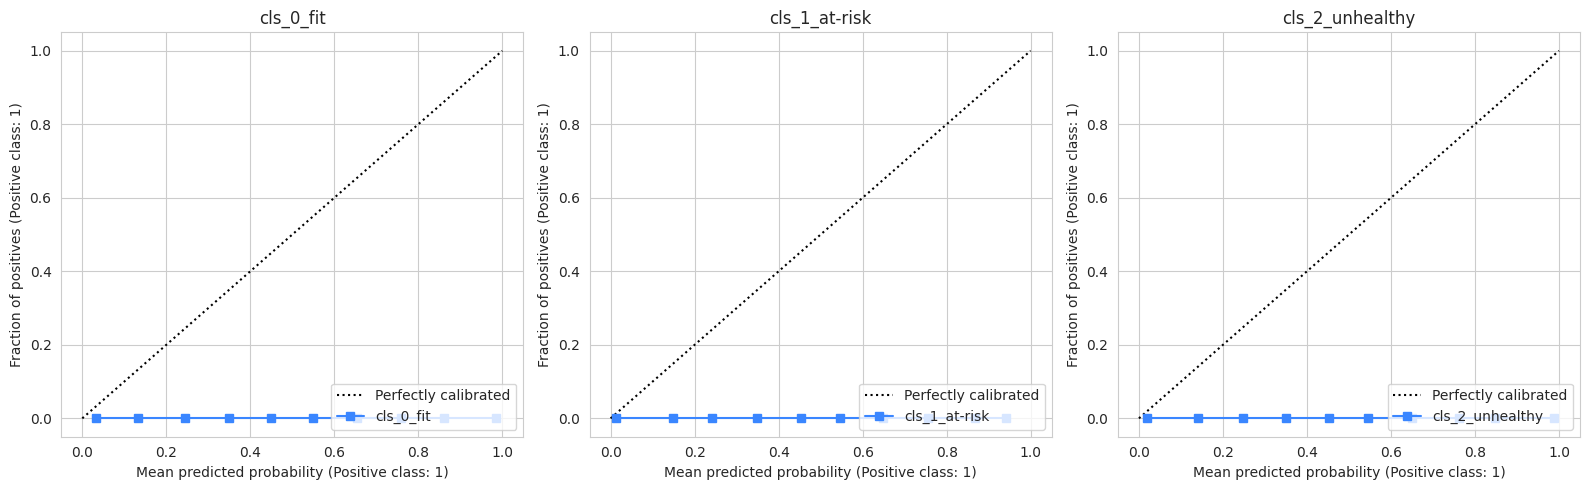

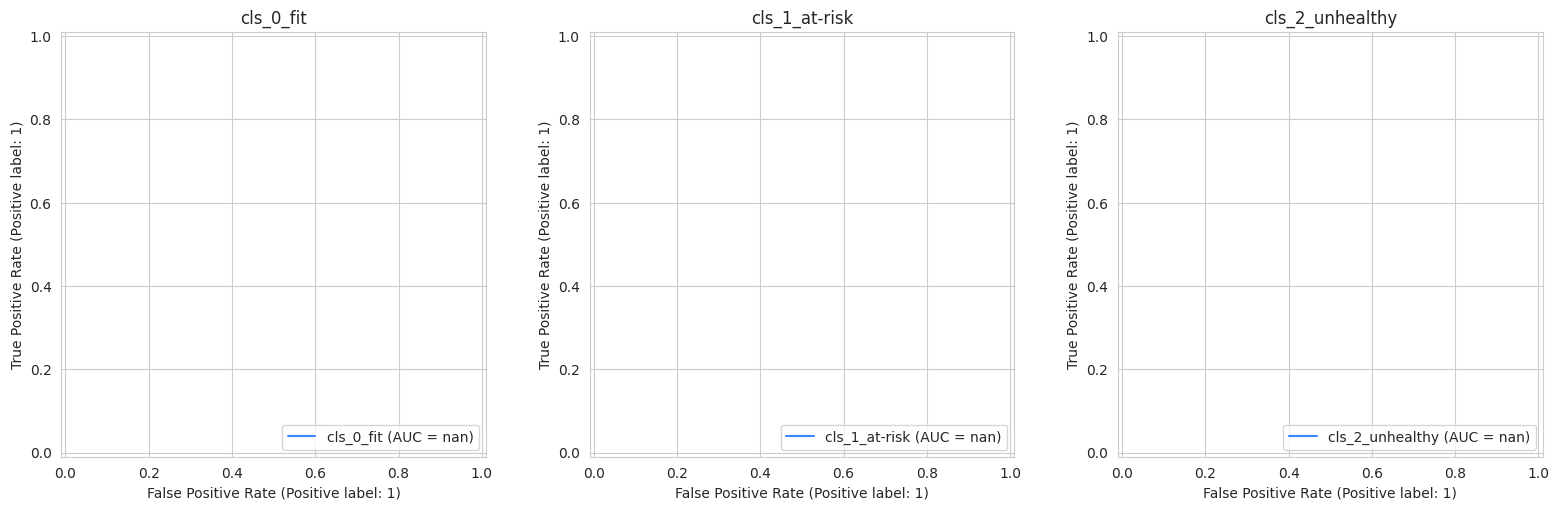

In [35]:
## -- Get oof predictions --
oof_predictions = []

for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            n = f"{k}_{str([*all_scores.values()][i]).split('.')[1]}"
            np.save(f"oof_{n}_.npy", y)
            print(f"{n} saved!")

            ## -- Plot oof distributions --
            y_labels = pd.Series(np.argmax(y, axis=1))
            classes = [*mapping.keys()]
            name0 = f"cls_0_{classes[0]}"
            name1 = f"cls_1_{classes[1]}"
            name2 = f"cls_2_{classes[2]}"

            y_cls_0 = (train_data[TARGET] == 0).astype(int)
            y_cls_1 = (train_data[TARGET] == 1).astype(int)
            y_cls_2 = (train_data[TARGET] == 2).astype(int)
            p_cls_0 = y[:, 0]
            p_cls_1 = y[:, 1]
            p_cls_2 = y[:, 2]

            _, axs = plt.subplots(1, 3, figsize=(16, 5))
            CalibrationDisplay.from_predictions(y_cls_0, p_cls_0, n_bins=10, name=name0, ax=axs[0])
            CalibrationDisplay.from_predictions(y_cls_1, p_cls_1, n_bins=10, name=name1, ax=axs[1])
            CalibrationDisplay.from_predictions(y_cls_2, p_cls_2, n_bins=10, name=name2, ax=axs[2])
            axs[0].set_title(name0)
            axs[1].set_title(name1)
            axs[2].set_title(name2)

            # plt.suptitle(n)
            plt.tight_layout()
            plt.show()

            _, axs = plt.subplots(1, 3, figsize=(16, 5))
            RocCurveDisplay.from_predictions(
                y_cls_0, p_cls_0, name=name0, ax=axs[0],
                sample_weight=get_sample_weights(y_cls_0, y_cls_0),
            )
            RocCurveDisplay.from_predictions(
                y_cls_1, p_cls_1, name=name1, ax=axs[1],
                sample_weight=get_sample_weights(y_cls_1, y_cls_1),
            )
            RocCurveDisplay.from_predictions(
                y_cls_2, p_cls_2, name=name2, ax=axs[2],
                sample_weight=get_sample_weights(y_cls_2, y_cls_2),
            )
            axs[0].set_title(name0)
            axs[1].set_title(name1)
            axs[2].set_title(name2)

            # plt.suptitle(n)
            plt.tight_layout()
            plt.show()

            print()

tabnet_94815 saved! (295753, 3)


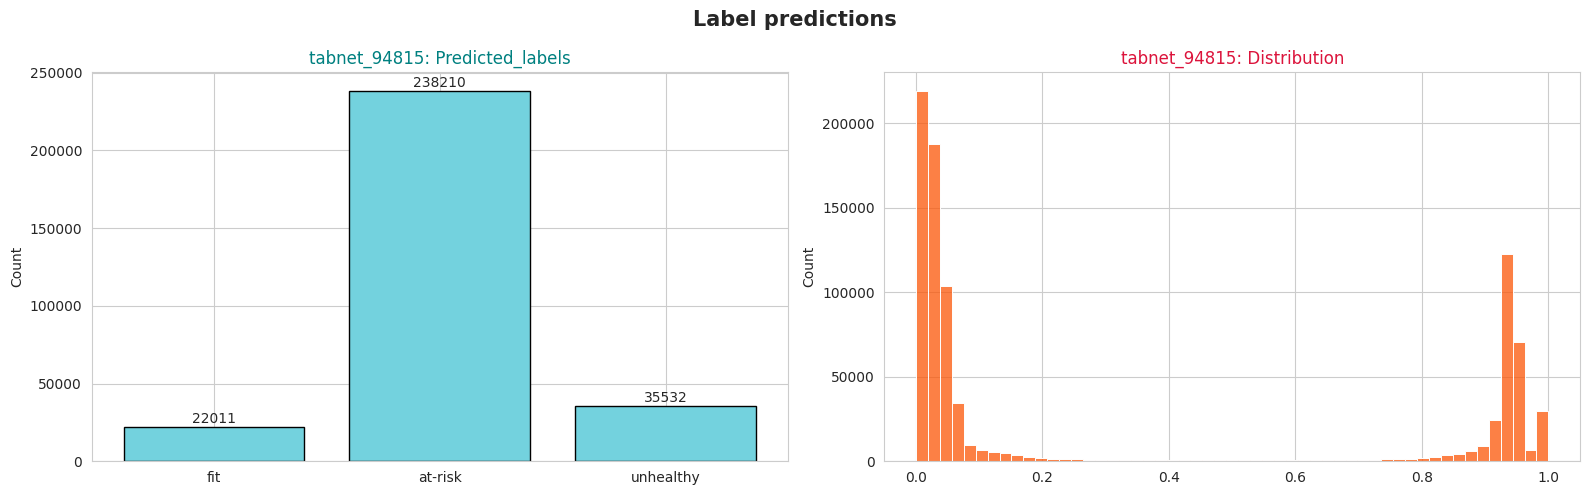


tabnet_vec_9483 saved! (295753, 3)


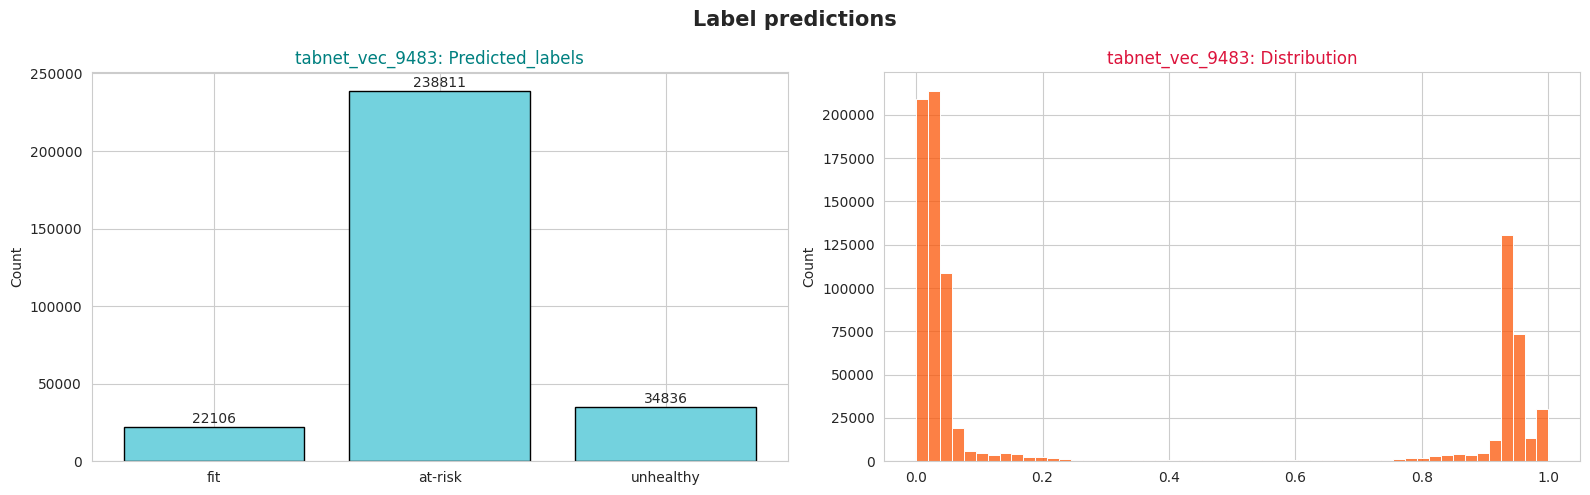

In [36]:
## -- Save TEST predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == 'test_preds':
            ## -- Base submission file --
            n = f"{k}_{str([*all_scores.values()][i]).split('.')[1]}"
            np.save(f"test_{n}_.npy", y)

            y_labels = np.argmax(y, axis=1)

            model_results[n] = pd.Series(y_labels).map(r_mapping)

            submit[TARGET] = pd.Series(y_labels).map(r_mapping)
            submit.to_csv(f'submit_{n}.csv', index=False)
            print(f'{n} saved! {y.shape}')

            fig, axs = plt.subplots(1, 2, figsize=(16, 5))

            counts = [np.sum(y_labels == _) for _ in range(len(mapping))]
            axs[0].bar([*mapping.keys()], counts, color='#73D2DE', edgecolor='k')
            axs[0].set_title(f"{n}: Predicted_labels", color='teal')
            axs[0].set_ylabel('Count')

            for i, c in enumerate(counts):
                axs[0].text(i, c+2500, str(c), ha='center', fontsize=10)

            sns.histplot(y.ravel(), ax=axs[1], color='#FB5607')
            axs[1].set_title(f"{n}: Distribution", color='crimson')

            plt.suptitle('Label predictions', fontsize=15, fontweight='semibold')

            plt.tight_layout()
            plt.show()

            print()

In [37]:
pd.DataFrame(model_results)

,tabnet_94815,tabnet_vec_9483
0,unhealthy,unhealthy
1,unhealthy,unhealthy
2,at-risk,at-risk
3,at-risk,at-risk
4,unhealthy,unhealthy
...,...,...
295748,fit,fit
295749,at-risk,at-risk
295750,unhealthy,unhealthy
295751,at-risk,at-risk


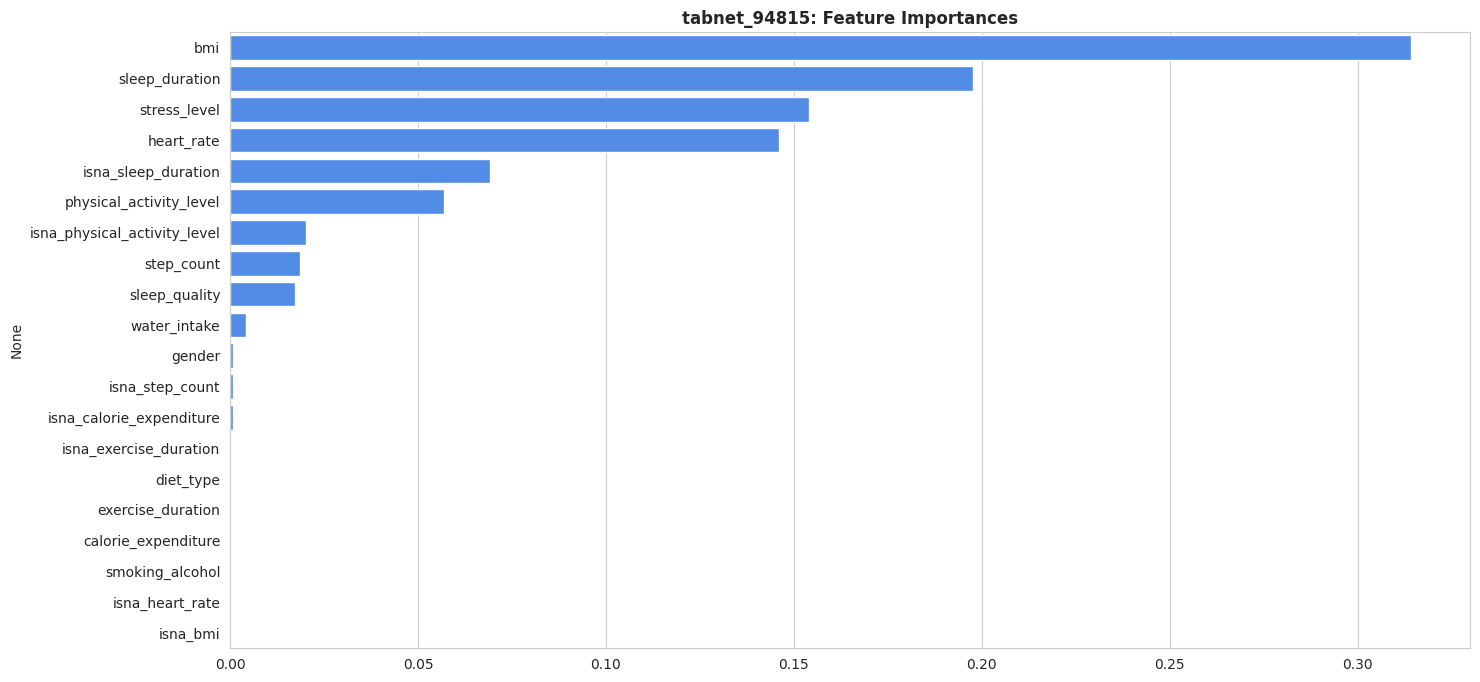

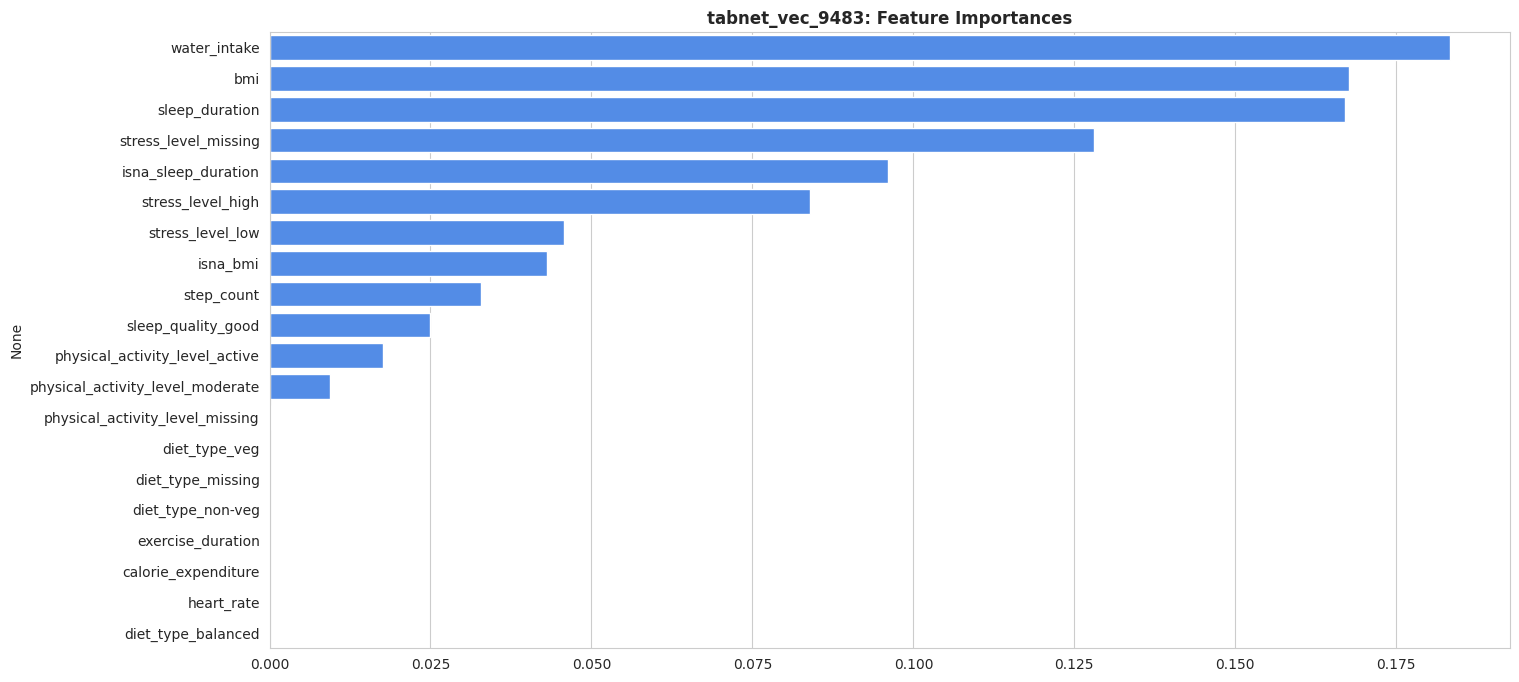

In [38]:
all_models = []

for i, _ in enumerate(list(all_predictions.keys())):
    model = all_predictions[list(all_predictions.keys())[i]]
    all_models.append(model)

## -- TabNet: FEATURE IMPORTANCES --
for i, m in enumerate(all_models):
    feat_imp = m['model'].feature_importances_
    features = m['columns']
    df_temp  = pd.Series(dict(zip(features, feat_imp))).sort_values(ascending=False)[:20]

    plt.figure(figsize=(16, 8))
    sns.barplot(y=df_temp.index, x=df_temp.values)
    plt.title(f"{[*model_results.keys()][i]}: Feature Importances", fontweight='semibold')

    # plt.tight_layout()
    plt.show()
    print()

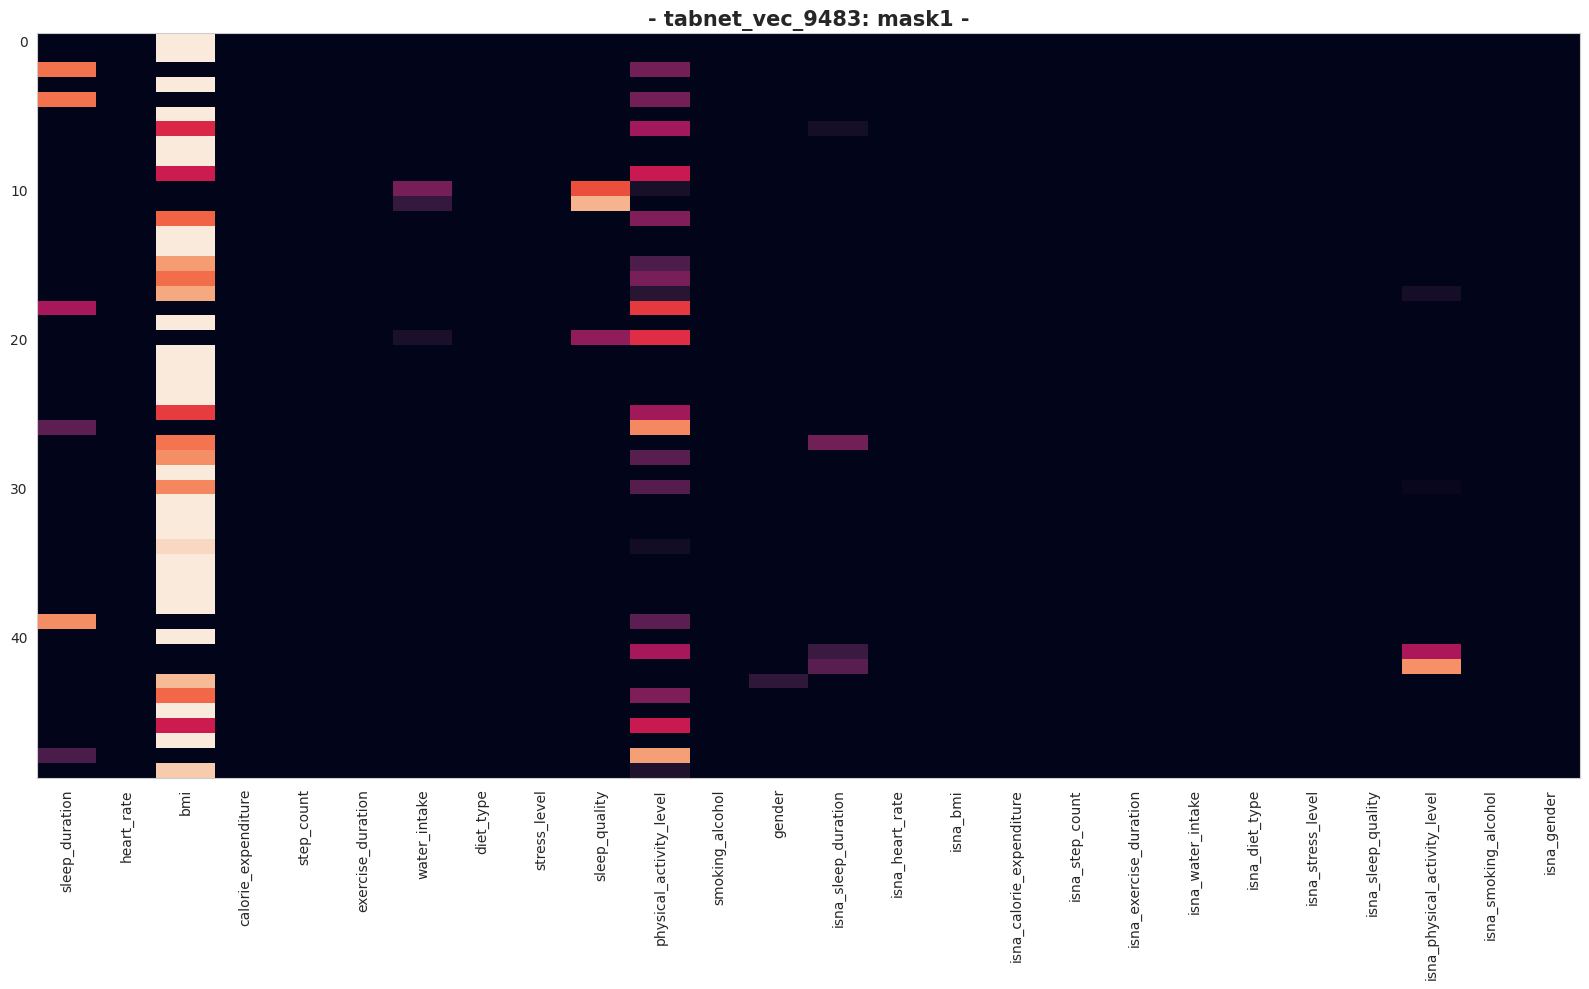

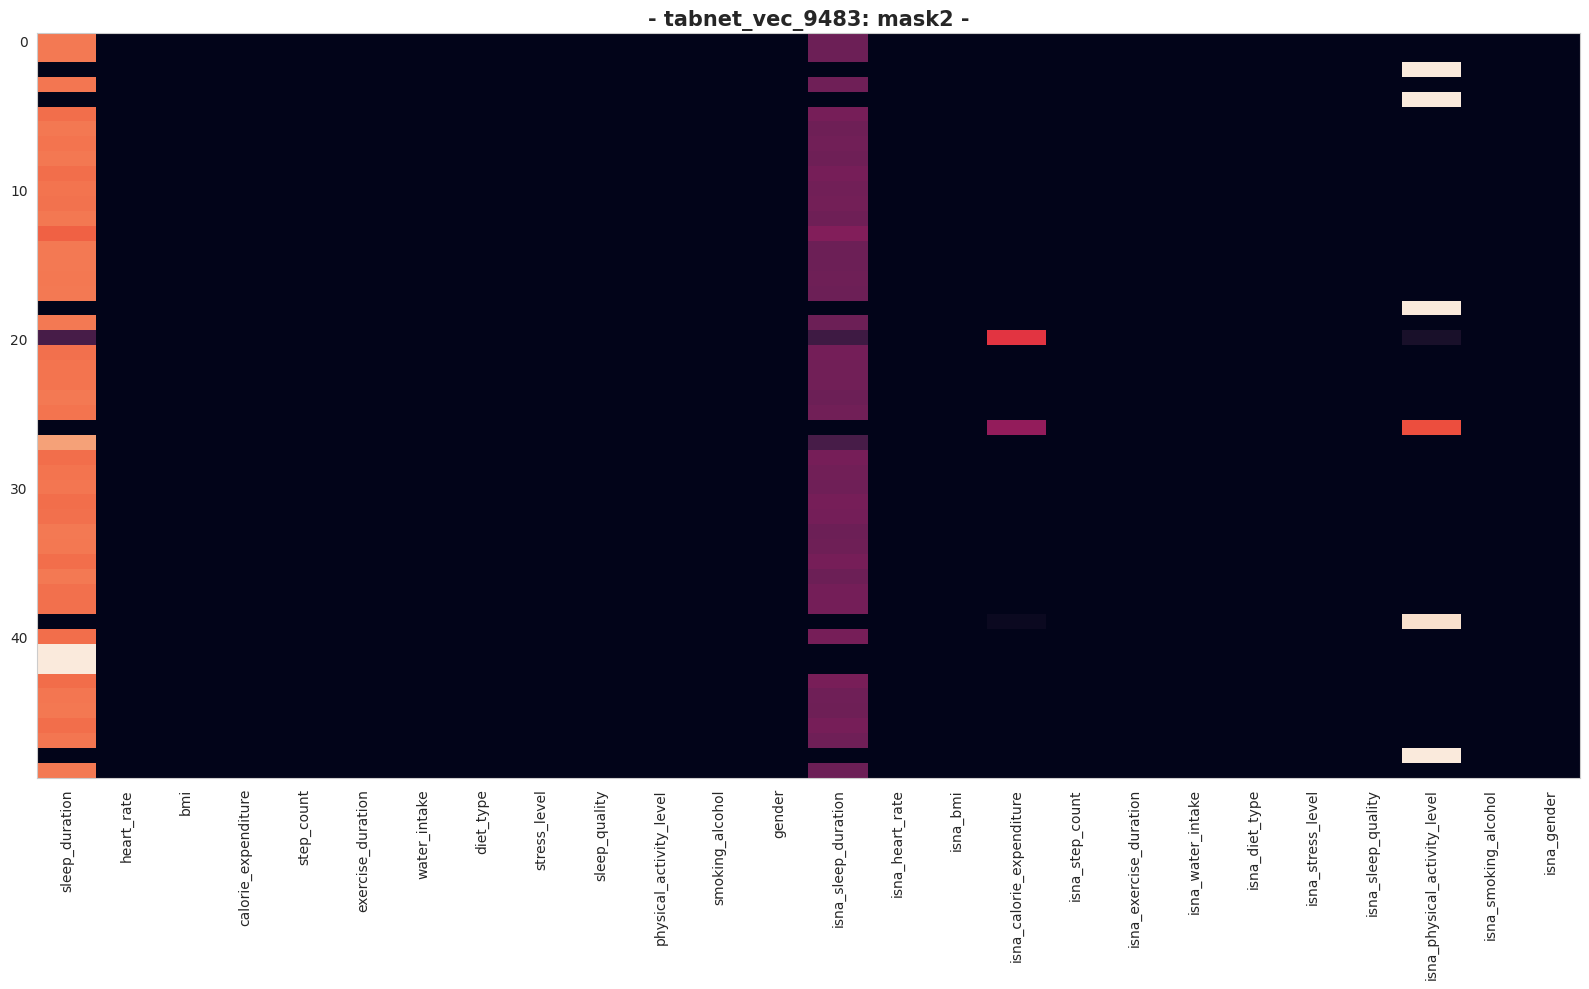

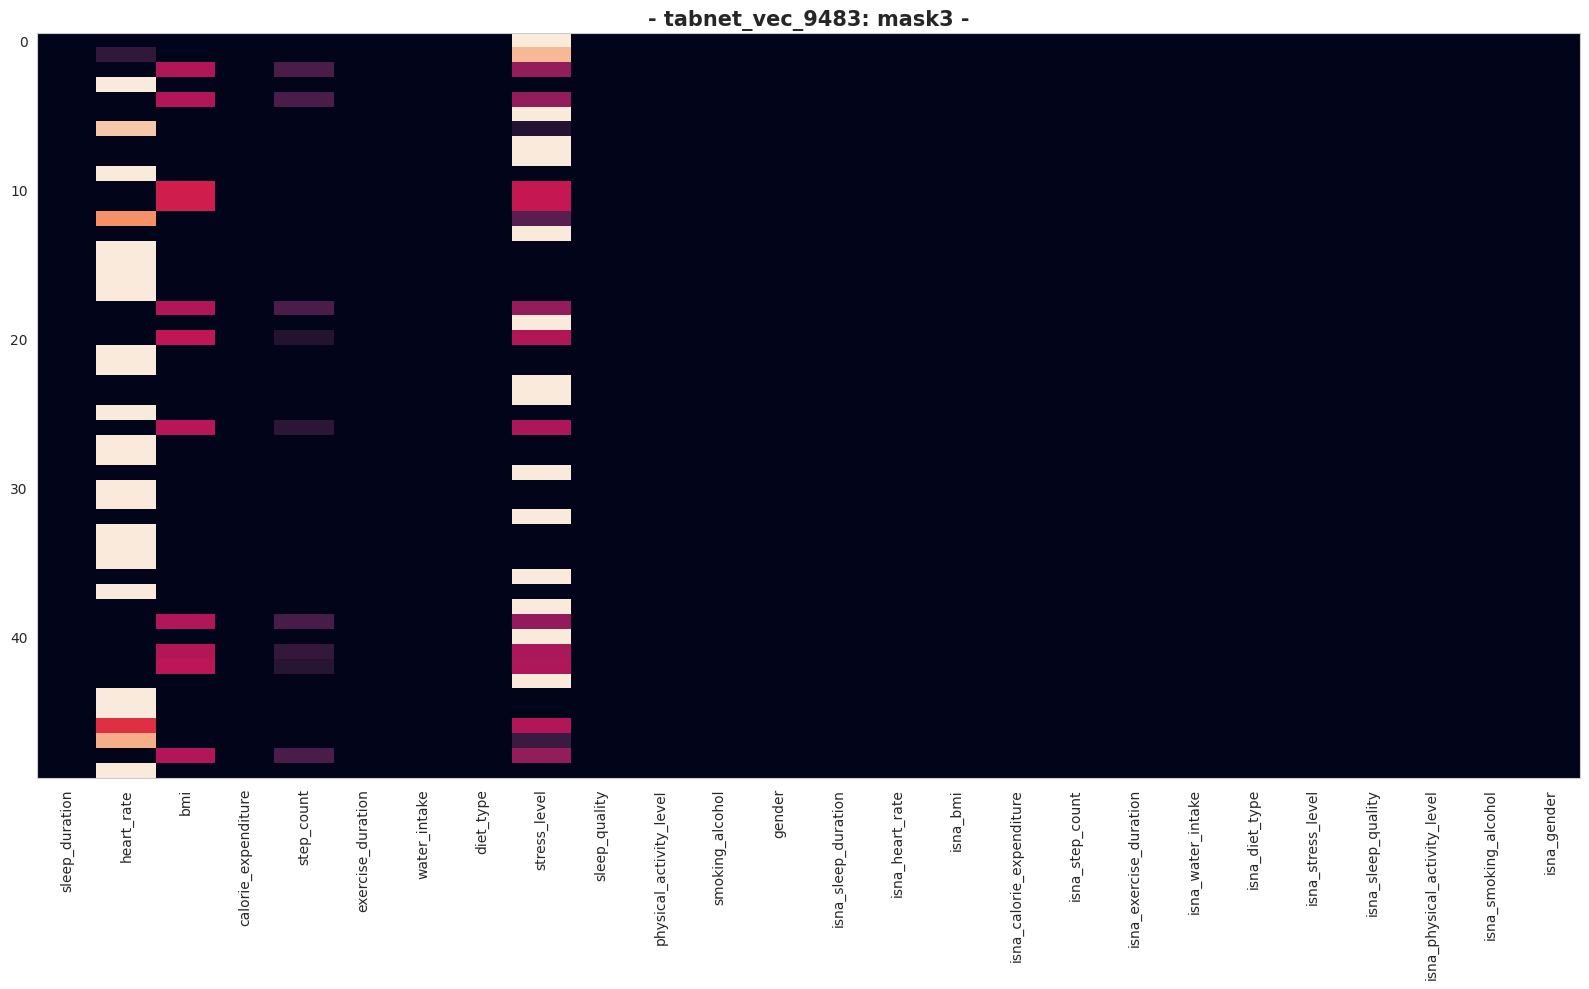

In [39]:
## -- Most used features --
explain_matrix, masks = all_models[0]['model'].explain(all_models[0]['val_data'].to_numpy())

for i in range(3):
    fig, ax = plt.subplots(1, 1, figsize=(16, 10))
    ax.imshow(masks[i][:50], aspect='auto')
    ax.set_title(f"- {n}: mask{i+1} -", size=15, weight='semibold')
    ax.set_xticks(range(len(all_models[0]['val_data'].columns)), all_models[0]['val_data'].columns)
    ax.tick_params('x', rotation=90)
    ax.grid()
    plt.tight_layout()
    plt.show()
    print()